# Hugging Face Transformers

[Hugging Face](https://huggingface.co/) is an AI-focused company whose goal is to advance and democratize AI. The company originally concentrated on NLP models but has since expanded its library to include pretrained models of other types, including [image-classification](https://huggingface.co/tasks/image-classification) models and [object-detection](https://huggingface.co/tasks/object-detection) models. Let's use some of Hugging Face's transformers to translate text, caption images, and more. Note that this notebook requires [PyTorch](https://pypi.org/project/torch/), which you can install with a `pip install torch` command if it isn't installed already. It also requires [sentencepiece](https://pypi.org/project/sentencepiece/) and [sacremoses](https://pypi.org/project/sacremoses/).

Let's start by using Hugging Face's [`opus-mt-en-fr`](https://huggingface.co/Helsinki-NLP/opus-mt-en-fr) model to translate English to French. This model achieves moderate to high [BLEU](https://en.wikipedia.org/wiki/BLEU) scores on a range of datasets:

In [1]:
%pip install sentencepiece sacremoses transformers --upgrade
import sys

from transformers import AutoTokenizer, AutoModelForSeq2SeqLM, utils

utils.logging.set_verbosity_error() # Suppress spurious warnings

# Initialize a tokenizer and model for translating English to French
tokenizer = AutoTokenizer.from_pretrained('Helsinki-NLP/opus-mt-en-fr')
# 1. Changed TFAutoModelForSeq2SeqLM to AutoModelForSeq2SeqLM
# 2. Removed from_pt=True
model = AutoModelForSeq2SeqLM.from_pretrained('Helsinki-NLP/opus-mt-en-fr')

# Tokenize the input text
text = 'When will your new book be available?'
# 3. Changed return_tensors='tf' to 'pt' for PyTorch
tokenized_text = tokenizer([text], return_tensors='pt')

# Translate the text and decode the output
translation = model.generate(**tokenized_text)
tokenizer.batch_decode(translation, skip_special_tokens=True)[0]

   ---------------------------------------- 0.0/1.2 MB ? eta -:--:--
   -------- ------------------------------- 0.3/1.2 MB ? eta -:--:--
   --------------------------------- ------ 1.0/1.2 MB 3.6 MB/s eta 0:00:01
   ---------------------------------------- 1.2/1.2 MB 3.3 MB/s  0:00:00
Note: you may need to restart the kernel to use updated packages.


C:\Users\sumida\anaconda3\envs\GenerativeAI\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 258/258 [00:00<00:00, 29180.52it/s]


'Quand votre nouveau livre sera-t-il disponible?'

Hugging Face also offers transformers for captioning images. The [`vit-gpt2-coco-en`](https://huggingface.co/ydshieh/vit-gpt2-coco-en) model was trained on the [COCO](https://cocodataset.org/#home) dataset and generates captions in English. Load an image for captioning:

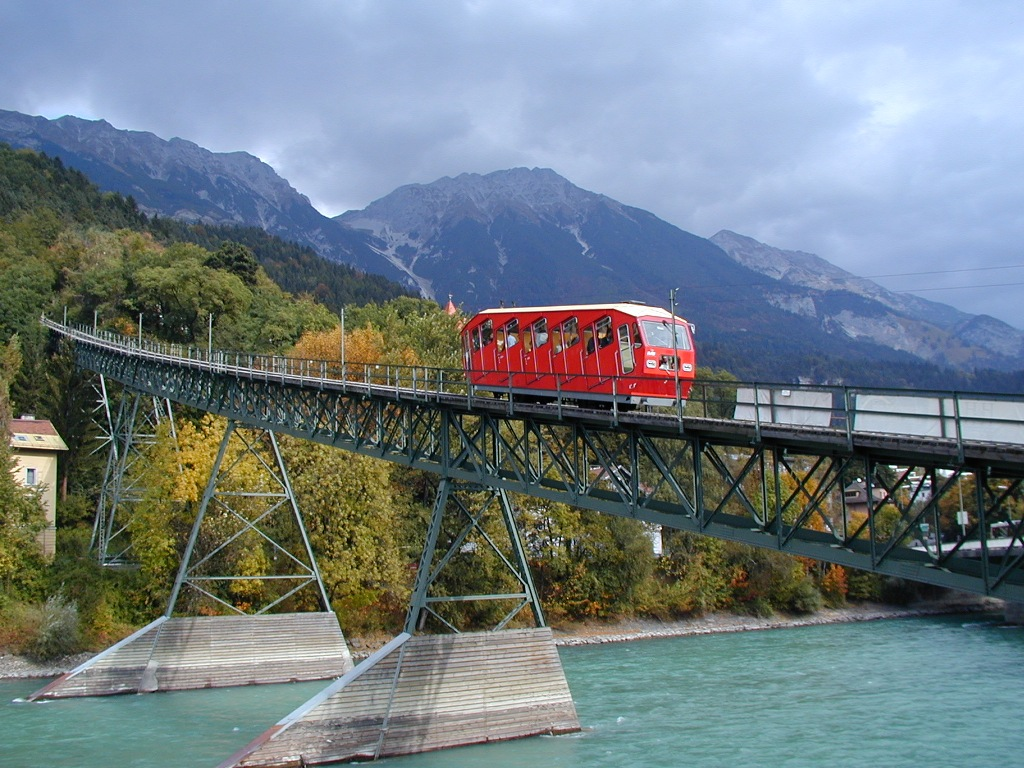

In [4]:
%matplotlib inline
import matplotlib.pyplot as plt
from PIL import Image

image = Image.open('Data/innsbruck.jpg')
display(image)

Now use `vit-gpt2-coco-en` to caption the image:

In [5]:
import torch
from transformers import ViTImageProcessor, AutoTokenizer, VisionEncoderDecoderModel

def predict(image, extractor, tokenizer, model):
    pixel_values = extractor(images=image, return_tensors='pt').pixel_values

    with torch.no_grad():
        output_ids = model.generate(pixel_values, max_length=16, num_beams=4, return_dict_in_generate=True).sequences

    preds = tokenizer.batch_decode(output_ids, skip_special_tokens=True)
    preds = [pred.strip() for pred in preds]
    return preds

id = 'ydshieh/vit-gpt2-coco-en'
image_processor = ViTImageProcessor.from_pretrained(id)
tokenizer = AutoTokenizer.from_pretrained(id)
model = VisionEncoderDecoderModel.from_pretrained(id)

predict(image, image_processor, tokenizer, model)

Loading weights: 100%|██████████| 444/444 [00:00<00:00, 4536.45it/s]
[transformers] We strongly recommend passing in an `attention_mask` since your input_ids may be padded. See https://huggingface.co/docs/transformers/troubleshooting#incorrect-output-when-padding-tokens-arent-masked.
You may ignore this warning if your `pad_token_id` (50256) is identical to the `bos_token_id` (50256), `eos_token_id` (50256), or the `sep_token_id` (None), and your input is not padded.


['a train traveling over a bridge over a river']

Suppose you're writing an app that uses object detection to detect license plates in a video feed and you wish to read license-plate numbers from the feed. Hugging Face has a solution for that, too. Their [`trocr-large-printed`](https://huggingface.co/microsoft/trocr-large-printed) model combines an image encoder with a text decoder to extract large printed text from images. Let's use it to read the number on a license plate. Start by loading the image:

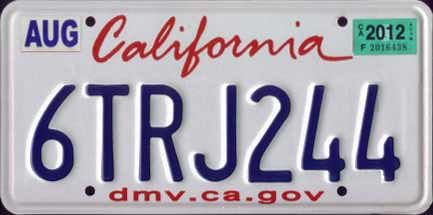

In [10]:
image = Image.open('Data/license-plate.jpg')
display(image)

Now use `trocr-large-printed` to extract the plate number:

In [1]:
# 1. Install the lightweight, python-pure OCR wrapper
%pip install easyocr --user

import easyocr
from PIL import Image

# 2. Initialize the reader (uses your working PyTorch backend automatically)
reader = easyocr.Reader(['en'], gpu=False)

# 3. Read text from your license plate image
result = reader.readtext('Data/license-plate.jpg')

# 4. Print out what it finds
for detection in result:
    # detection format is: (bounding_box, text, confidence)
    print("OCR Text Found:", detection[1])

Note: you may need to restart the kernel to use updated packages.


Using CPU. Note: This module is much faster with a GPU.


Progress: |██████████████████████████████████████████████████| 100.0% Complete

Progress: |██████████████████████████████████████████████████| 100.0% Complete

C:\Users\sumida\anaconda3\envs\GenerativeAI\Lib\site-packages\torch\ao\nn\quantized\dynamic\modules\rnn.py:162: UserWarning: torch.quantize_per_tensor, torch.quantize_per_channel and other quantized tensor creation functions that produce tensors with dtype torch.quint8, torch.qint8, and torch.qint32 are deprecated and will be removed in a future PyTorch release. Please see https://github.com/pytorch/pytorch/issues/184982 for more information. (Triggered internally at D:\bld\libtorch_1785823022294\work\aten\src\ATen\quantized\Quantizer.cpp:116.)
  w_ih = torch.quantize_per_tensor(
C:\Users\sumida\anaconda3\envs\GenerativeAI\Lib\site-packages\torch\utils\data\dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


OCR Text Found: AuG
OCR Text Found: 82012 :
OCR Text Found: 'Calikoia "
OCR Text Found: 6TRJZLL
OCR Text Found: dmv ca-gov


Hugging Face’s transformers package contains several pretrained BERT models already fine-tuned for specific tasks. One example is the [`minilm-uncased-squad2`](https://huggingface.co/deepset/minilm-uncased-squad2) model, which was trained with Stanford’s [SQuAD 2.0](https://rajpurkar.github.io/SQuAD-explorer/) dataset to answer questions by extracting text from contexts provided to it. To demonstrate, use the following statements to load the pretrained MiniLM model from the Hugging-Face hub and a tokenizer to tokenize text input to the model:

In [4]:
import torch
from transformers import AutoTokenizer, AutoModelForQuestionAnswering

id = 'deepset/minilm-uncased-squad2'
tokenizer = AutoTokenizer.from_pretrained(id)
model = AutoModelForQuestionAnswering.from_pretrained(id)

# Define a helper function to answer questions manually without using pipelines
def answer_question(question, context):
    inputs = tokenizer(question, context, return_tensors="pt")
    with torch.no_grad():
        outputs = model(**inputs)
    
    # Extract the highest probability start and end word positions
    answer_start = torch.argmax(outputs.start_logits)
    answer_end = torch.argmax(outputs.end_logits) + 1
    
    # Decode the tokens back into a readable string string
    answer = tokenizer.convert_tokens_to_string(
        tokenizer.convert_ids_to_tokens(inputs["input_ids"][0][answer_start:answer_end])
    )
    return answer

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 4353.52it/s]
[transformers] BertForQuestionAnswering LOAD REPORT from: deepset/minilm-uncased-squad2
Key                      | Status     |  | 
-------------------------+------------+--+-
bert.pooler.dense.weight | UNEXPECTED |  | 
bert.pooler.dense.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Now use the model to answer a question by extracting text from a paragraph:

In [5]:
question = 'What does NLP stand for?'

context = 'Natural Language Processing, or NLP, encompasses a variety of \
activities, including text classification, keyword and topic \
extraction, text summarization, and language translation. The \
accuracy of NLP models has improved in recent years for a variety \
of reasons, not the least of which are newer and better ways of \
converting words and sentences into dense vector representations \
that incorporate context, and a relatively new neural-network \
architecture called the transformer that can zero in on the most \
meaningful words and even differentiate between multiple meanings \
of the same word.'

answer_question(question=question, context=context)

'natural language processing'

Is the answer accurate? A human could easily read the paragraph and come up with the same answer, but the fact that a deep-learning model can do it indicates that the model displays some level of reading comprehension. Observe that the output contains the answer to the question as well as a confidence score and the starting and ending indexes of the answer in the paragraph. Try it with another question:

In [6]:
answer_question(question='What are some examples of NLP?', context=context)

'text classification, keyword and topic extraction, text summarization, and language translation'

Feel free to try it with questions and contexts of your own.